In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from pandas_ta.volatility import kc 

df = pd.read_csv("../data/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
df['ema25'] = df['Close'].ewm(span=25, adjust=False).mean()

df.reset_index(drop=True, inplace=True)
df=df[df.High!=df.Low]

df=df[0:2000]

# Bolinger Bands
df.ta.bbands(append=True, length=20, std=2)

# Initialize Keltner Channel Indictor
kc=kc(high=df['High'], low=df['Low'], close=df["Close"], window=20)

#Bolinger Band Upper - Keltner Channel Upper
df['bbu_minus_kcu'] = df['BBU_20_2.0'] - kc['KCUe_20_2']

pd.options.mode.copy_on_write = True

In [2]:
import enum
class EMA25(enum.Enum):
    PRICE_ACCION_NEUTRAL = 0
    PRICE_ACCION_UNDER = 1
    PRICE_ACCION_OVER = 2

In [62]:
def detectSqueeze(candle):

    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 
    isSqueeze = EMA25['PRICE_ACCION_NEUTRAL'].value
    
    if (df.iloc[candle]).bbu_minus_kcu<=0:
        if close<ema25:
            isSqueeze = EMA25['PRICE_ACCION_UNDER'].value
        else:
            isSqueeze = EMA25['PRICE_ACCION_OVER'].value
            
    return isSqueeze  

def detectSqueezeCloseToEMA(candle):

    isSqueeze = EMA25['PRICE_ACCION_NEUTRAL'].value
    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 
    high = (df.iloc[candle]).High
    low = (df.iloc[candle]).Low
    squeeze = (df.iloc[candle])['squeeze']
    zoneWidth = .30
    
    if squeeze==1:
        
        if (abs(low-ema25) <= zoneWidth):
            isSqueeze = EMA25['PRICE_ACCION_OVER'].value

        if (abs(high-ema25) <= zoneWidth):
            isSqueeze = EMA25['PRICE_ACCION_UNDER'].value
            
    return isSqueeze

def detectPosibleBreak(candle):

    window = 3
    posibleBreak = EMA25['PRICE_ACCION_NEUTRAL'].value
    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 
    squeezeCloseToEma = (df.iloc[candle]).squeezeCloseToEma 

    if (candle <= (window)) or (candle+window+1 >= len(df)):
        return posibleBreak
    
    localdf = df.iloc[candle-window:candle]

    val = localdf[localdf['squeezeCloseToEma'] == EMA25['PRICE_ACCION_UNDER'].value]
    
    lastTreeUnder = localdf[localdf['squeezeCloseToEma'] == EMA25['PRICE_ACCION_UNDER'].value].tail(3).values
    lastTreeOver = localdf[localdf['squeezeCloseToEma'] == EMA25['PRICE_ACCION_OVER'].value].tail(3).values

    if len(lastTreeUnder) == window and close<ema25 and squeezeCloseToEma:
        posibleBreak = EMA25['PRICE_ACCION_UNDER'].value
    elif len(lastTreeOver) == window and close>ema25 and squeezeCloseToEma:
        posibleBreak = EMA25['PRICE_ACCION_OVER'].value
    else:
        posibleBreak = EMA25['PRICE_ACCION_NEUTRAL'].value
            
    return posibleBreak
    
df['squeeze'] = df.apply(lambda row: detectSqueeze(row.name), axis=1)
df['squeezeCloseToEma'] = df.apply(lambda row: detectSqueezeCloseToEMA(row.name), axis=1)
df['posibleBreak'] = df.apply(lambda row: detectPosibleBreak(row.name), axis=1)

In [63]:
def posibleBreakArea(x):
    extraSpace = 1
    if (x['posibleBreak']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['posibleBreak']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace    
    else:
        return np.nan
        
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeeze']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeeze']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan

df['squezzeArea'] = df.apply(lambda row: squezzeArea(row), axis=1)
df['squeezeCloseToEmaArea'] = df.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
df['posibleBreakArea'] = df.apply(lambda row: posibleBreakArea(row), axis=1)

#df.to_csv('squezze.csv', index=False)

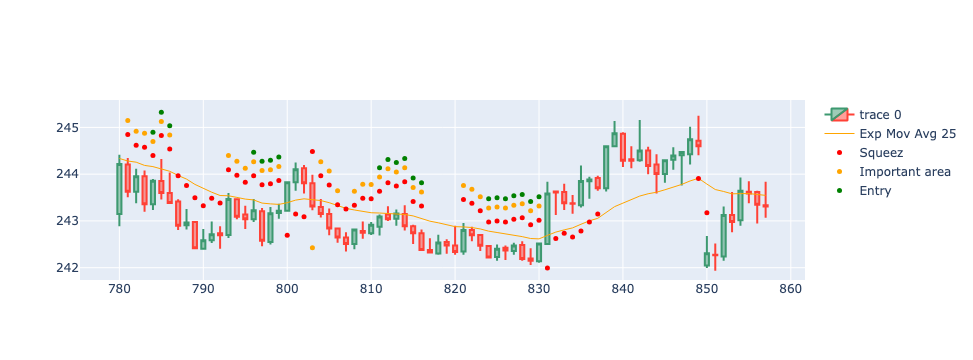

In [64]:
import plotly.io as pio
import plotly.graph_objects as go  
import numpy as np

'''
0:78
78:156
156:234
234:312
312:390 *
390:468 
468:546 *
546:624 *
624:702 * 
702:780 *
780:858
858:936
936:1014
1014:1092
1092:1170
1170:1248
1248:1326
1326:1404
1404:1482
1482:1560
1560:1638
1638:1716
1716:1794
1794:1872
1872:1950
1950:2028
2028:2106
'''
dfpl = df[780:858]

fig = go.Figure(data=[
                    go.Candlestick(x=dfpl.index,
                                    open=dfpl['Open'],
                                    high=dfpl['High'],
                                    low=dfpl['Low'],
                                    close=dfpl['Close']),
                    go.Scatter(x=dfpl.index, y=dfpl['ema25'], line=dict(color='orange', width=1), name="Exp Mov Avg 25")
                ])

fig.add_scatter(x=dfpl.index, y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl.index, y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl.index, y=dfpl['posibleBreakArea'], mode="markers", marker=dict(size=5, color="green"), name="Entry")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()